In [4]:
%load_ext autoreload
%autoreload 2
import seaborn as sns
import matplotlib.pyplot as plt

# Set global Seaborn style
sns.set_theme(
    style="whitegrid",   # or "ticks" for minimalist look
    context="paper",     # "notebook", "talk", "poster", "paper"
    font="DejaVu Sans"
)

%config InlineBackend.figure_format = 'retina'


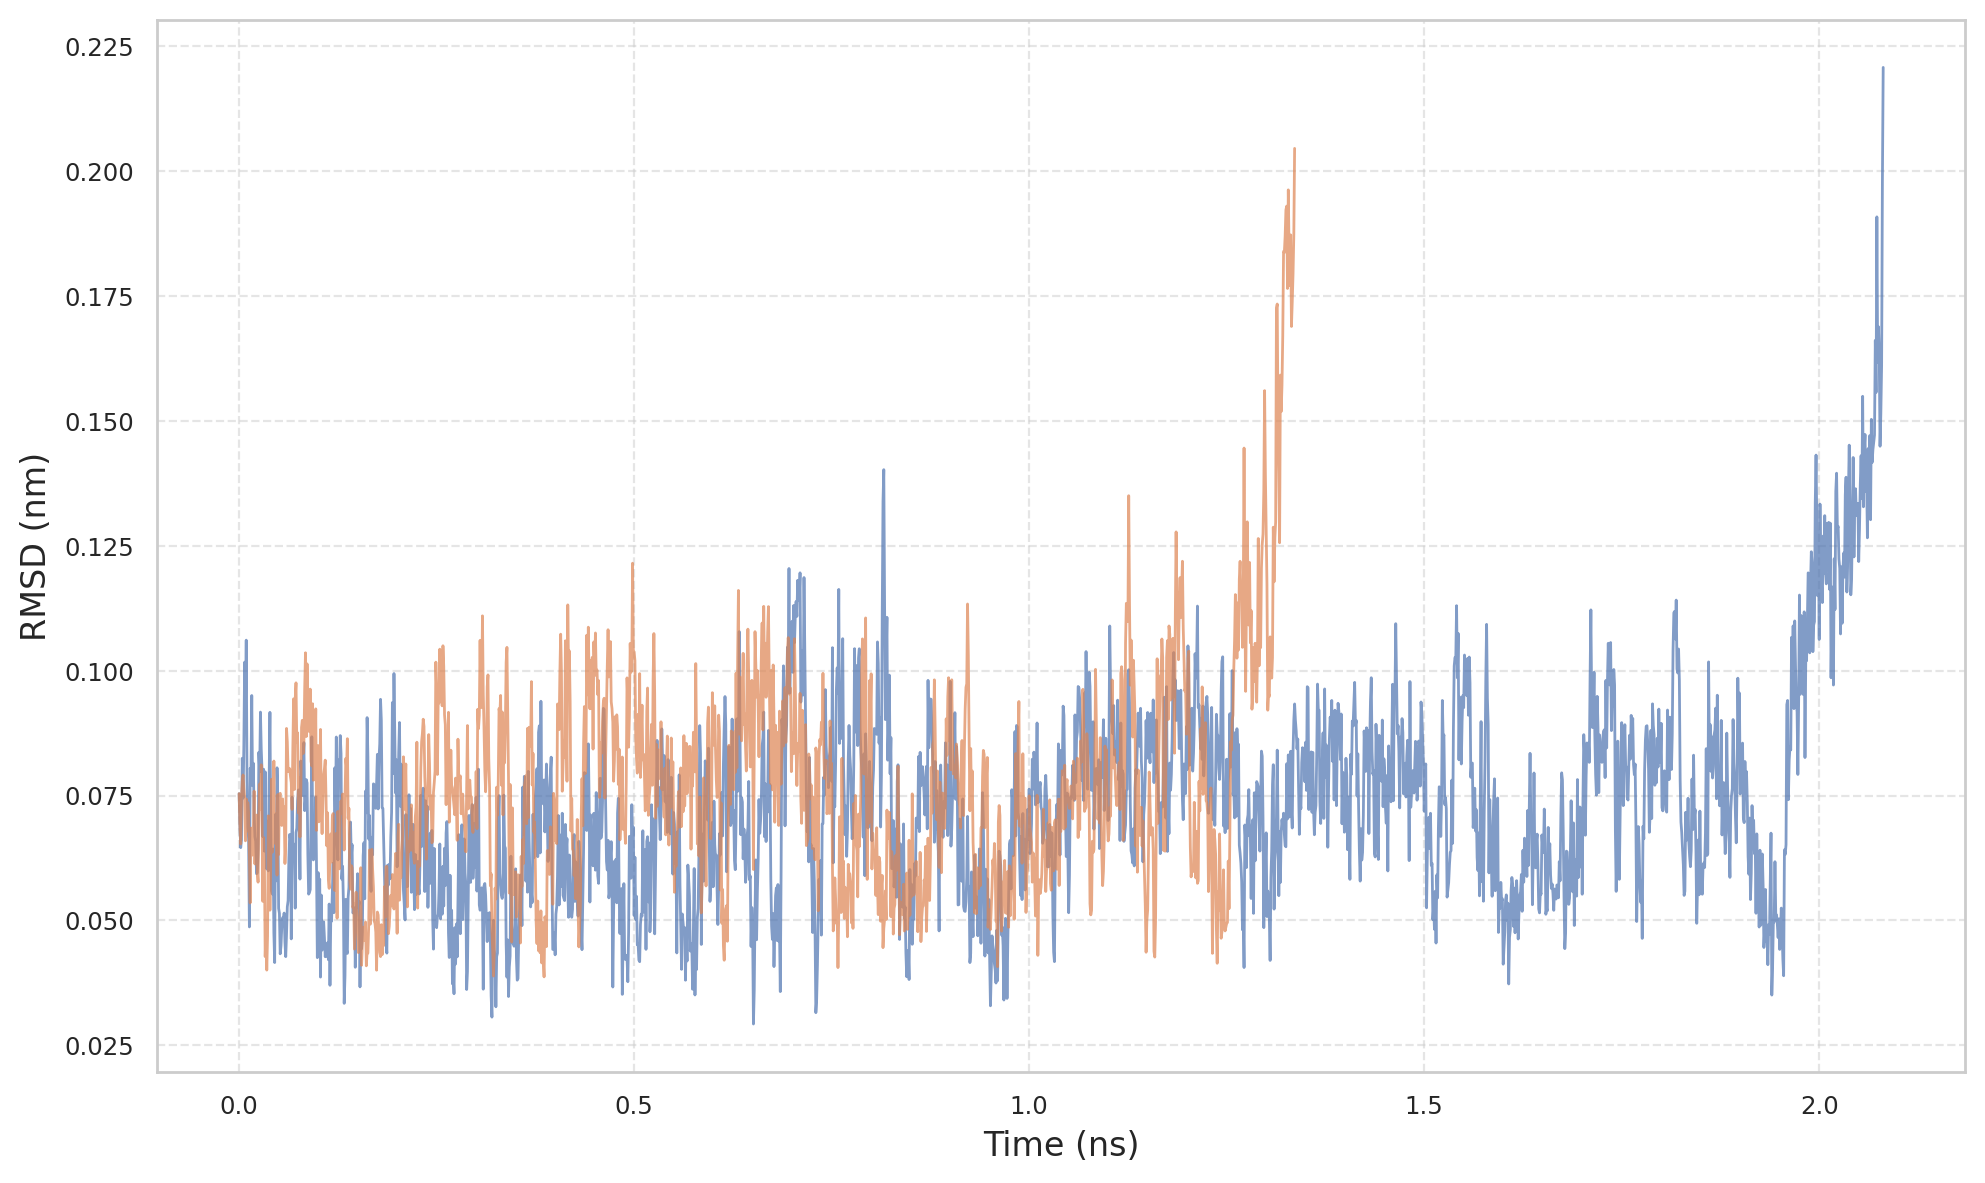

In [5]:
import matplotlib
# %matplotlib widget
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def read_colvar(colvar_file: Path) -> pd.DataFrame:
    # Extract headers from the FIELDS line
    with colvar_file.open() as f:
        headers = None
        for line in f:
            if line.startswith("#! FIELDS"):
                headers = line.replace("#! FIELDS", "").strip().split()
                break
    if headers is None:
        raise ValueError(f"No '#! FIELDS' line found in {colvar_file}")

    # Read the file while skipping all comment lines
    return pd.read_csv(
        colvar_file,
        sep=r"\s+",
        comment="#",
        names=headers,
        engine="python"
    )

proteins = ["chignolin"]

plt.figure(figsize=(10, 6))

threshold = 0.2  # nm

for protein_name in proteins:
    base_path = Path(f"../data/{protein_name}/output")

    for i in range(4050, 4052):
        run_name = f"run_{i:03d}"
        colvar_file = base_path / run_name / f"HLDA_COLVAR_{i:03d}"

        df = read_colvar(colvar_file)

        # find first index where RMSD > threshold
        idx = df.index[df["rmsd"] > threshold]
        if len(idx) > 0:
            cutoff = idx[0]
            df = df.loc[:cutoff]   # keep data up to and including that frame

        times = df["time"] * 1e-3  # ps → ns
        rmsd = df["rmsd"]

        plt.plot(times, rmsd, linewidth=1.0, alpha=0.7)


plt.xlabel("Time (ns)", fontsize=12)
plt.ylabel("RMSD (nm)", fontsize=12)
# plt.legend(fontsize="small", ncol=2, frameon=False)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

plt.show()


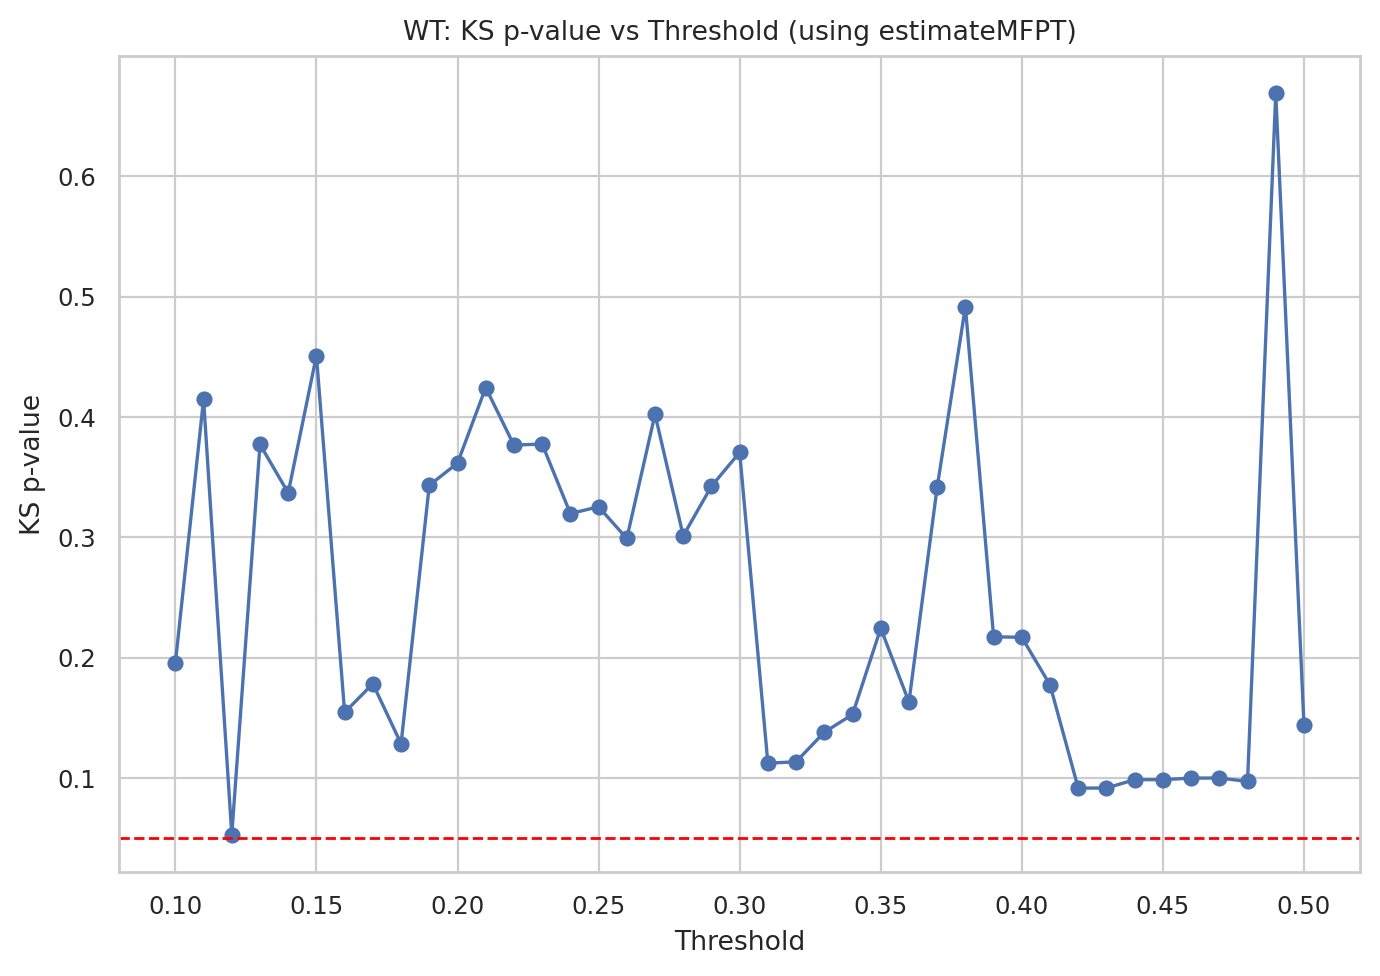

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from scipy import stats
from common.utils import estimateMFPT

with open("../data/mfpt-pace=25000-granular.pkl", "rb") as f:
    all_mfpt = pickle.load(f)

def plot_wt_p_vs_threshold(all_mfpt):
    ths = np.array(sorted(all_mfpt['chignolin'].keys(), key=float), dtype=float)

    pvals, mfpts, ks = [], [], []
    for th in ths:
        s = np.array(all_mfpt['chignolin'][th])
        mfpt, k = estimateMFPT(s)         # get MFPT and how many samples it kept
        sub = np.sort(s)
        sub = s[:k]                       # use only those k fastest samples
        tau = sub.mean()                  # exponential MLE
        _, p = stats.kstest(sub, "expon", args=(0, tau))  # one-sample KS test
        pvals.append(p)
        mfpts.append(mfpt)
        ks.append(k)

    df = pd.DataFrame({
        "threshold": ths,
        "p": pvals,
        "mfpt": mfpts,
        "k_used": ks
    }).set_index("threshold")

    plt.figure(figsize=(7, 5))
    plt.plot(df.index, df["p"], marker="o")
    plt.axhline(0.05, linestyle="--", color="red", linewidth=1)
    plt.xlabel("Threshold")
    plt.ylabel("KS p-value")
    plt.title("WT: KS p-value vs Threshold (using estimateMFPT)")
    plt.tight_layout()
    plt.show()

    return df

df_wt_p = plot_wt_p_vs_threshold(all_mfpt)


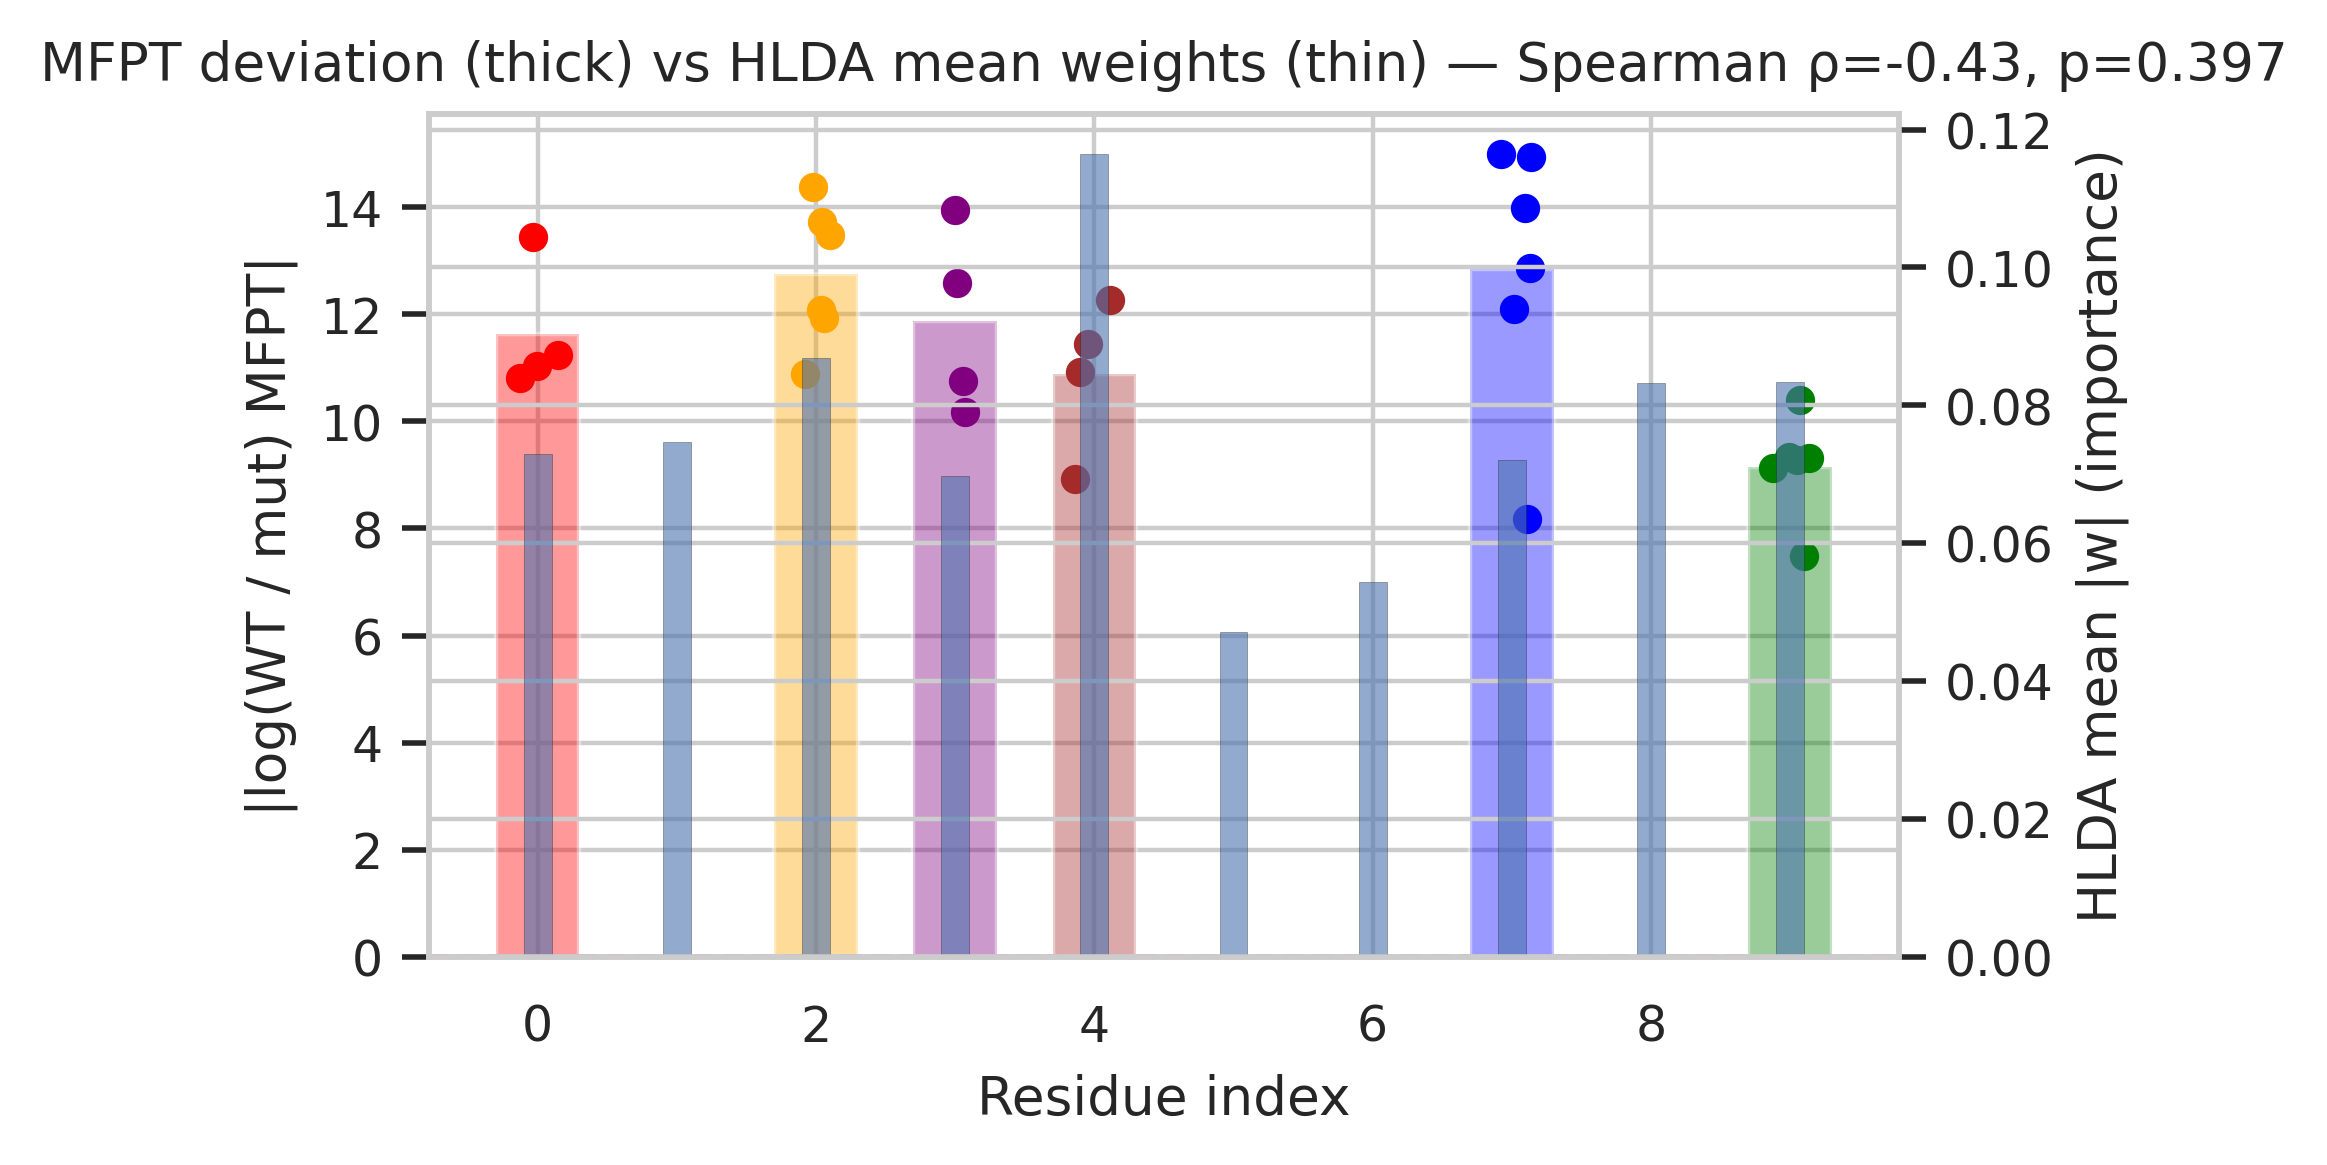

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from common.consts import res_colors

from common.utils import collect_df
with open("../data/mfpt-pace=25000.pkl", "rb") as f:
    all_mfpt = pickle.load(f)

thresholds = np.array(list(all_mfpt['chignolin'].keys()))
df = collect_df(False, all_mfpt, thresholds[1])
importance = {4:0.1165, 2:0.0868, 9:0.0834, 8:0.0833, 1:0.0747, 0:0.0730, 7:0.0720, 3:0.0697, 6:0.0544, 5:0.0471}

wt = float(df.loc['WT', 'mfpt'])

med_abs = {}
dist_by_res = {}
for i, g in df.groupby("residue_idx"):
    i = int(i)
    r = np.log(g['mfpt'].to_numpy())
    d = np.abs(r)
    med_abs[i] = np.mean(d)
    dist_by_res[i] = d

residues = sorted(set(range(10)) | set(importance.keys()) | set(med_abs.keys()))

fig, ax = plt.subplots(figsize=(5,3), dpi=200)
for i in residues:
    if i in med_abs:
        ax.bar(i, med_abs[i], color=res_colors[i], alpha=0.4, width=0.6)
        d = dist_by_res[i]
        x_jitter = np.random.uniform(-0.15, 0.15, size=len(d))
        ax.scatter(np.full(len(d), i) + x_jitter, d, color=res_colors[i], s=20, zorder=3)

ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel("Residue index")
ax.set_ylabel("|log(WT / mut) MFPT|")

ax2 = ax.twinx()
imp_vals = [importance.get(i, np.nan) for i in residues]
ax2.bar(residues, imp_vals, width=0.2, alpha=0.6, edgecolor='k', linewidth=0.1)
ax2.set_ylabel("HLDA mean |w| (importance)")

x = np.array([med_abs.get(i, np.nan) for i in residues], float)
y = np.array([importance.get(i, np.nan) for i in residues], float)
mask = ~np.isnan(x) & ~np.isnan(y)
rho, p = spearmanr(x[mask], y[mask]) if mask.any() and mask.sum()>1 else (np.nan, np.nan)
ax.set_title(f"MFPT deviation (thick) vs HLDA mean weights (thin) — Spearman ρ={rho:.2f}, p={p:.3g}")

fig.tight_layout()
plt.show()


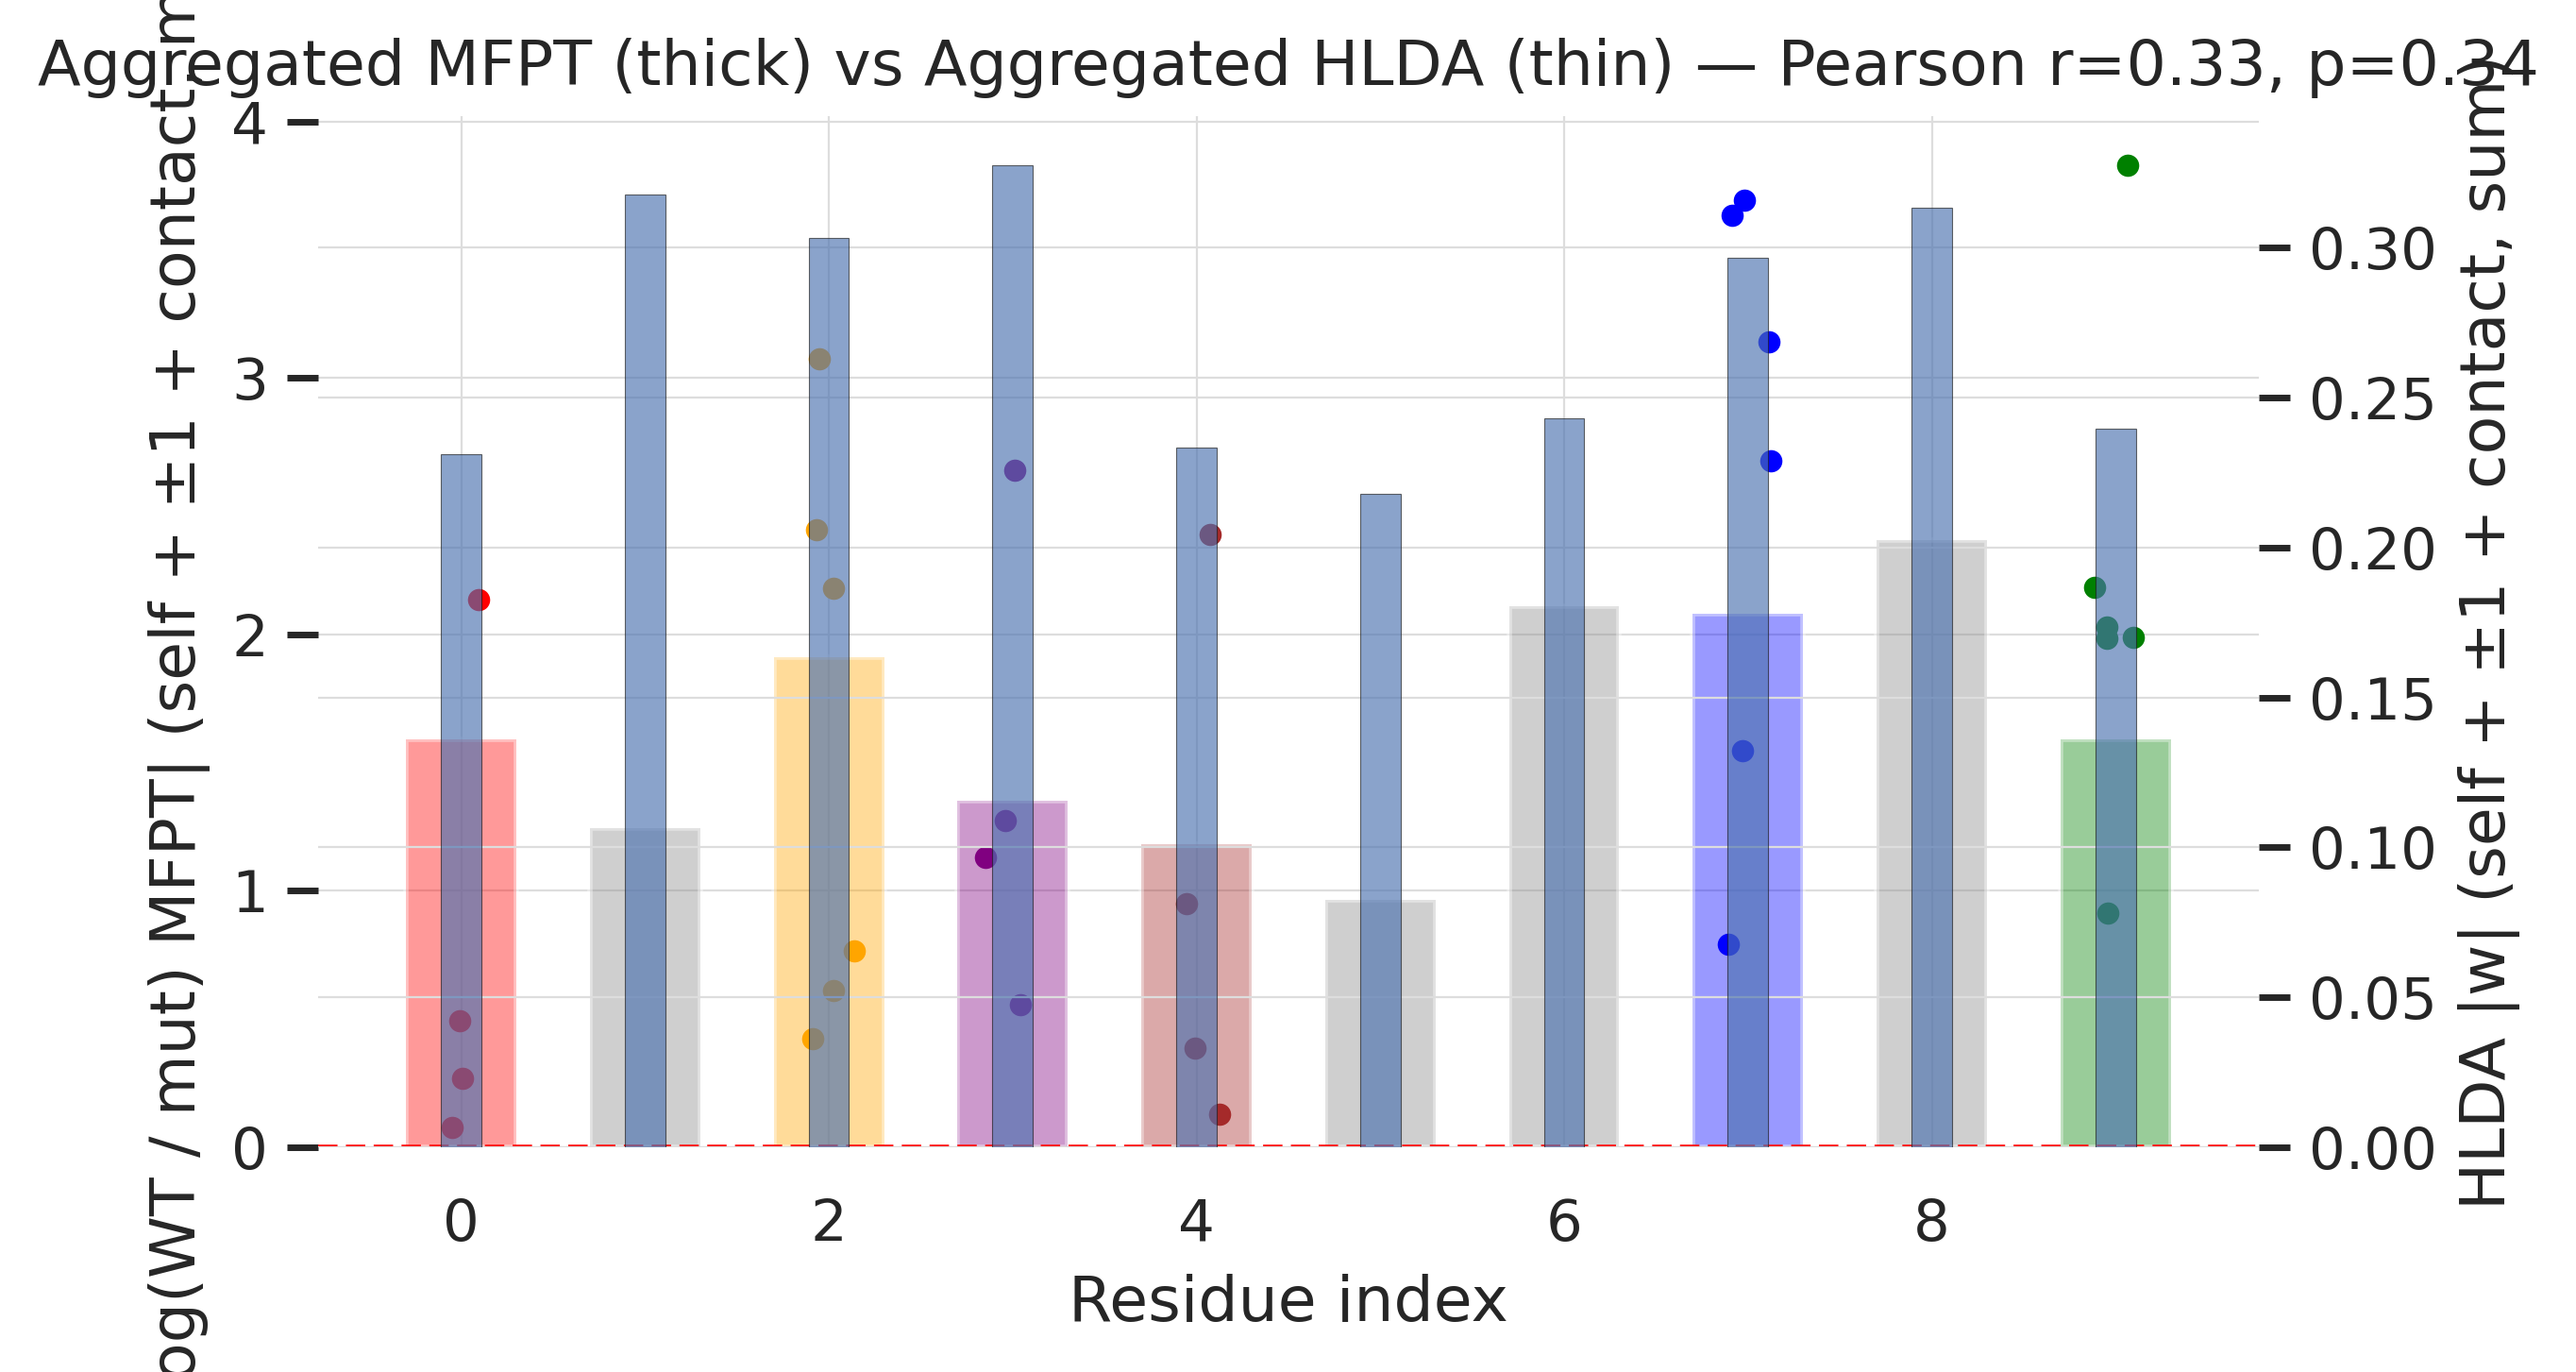

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import pickle
from common.utils import collect_df
from common.consts import res_colors

with open("../data/mfpt-pace=25000.pkl", "rb") as f:
    all_mfpt = pickle.load(f)

thresholds = np.array(list(all_mfpt['chignolin'].keys()))
df = collect_df(False, all_mfpt, thresholds[1])

importance = {4:0.1165, 2:0.0868, 9:0.0834, 8:0.0833, 1:0.0747, 0:0.0730, 7:0.0720, 3:0.0697, 6:0.0544, 5:0.0471}
contacts = {0:[9], 9:[0], 1:[8], 8:[1], 2:[7], 7:[2], 3:[6], 6:[3], 4:[], 5:[]}

def color_for(i, default="#888"):
    return res_colors.get(i, res_colors.get(str(i), default))

def seq_neighbors(i, R=1, n=10):
    return [j for j in range(n) if j != i and abs(j - i) <= R]

# MFPT per-residue distances
wt = float(df.loc['WT', 'mfpt'])
dist_by_res = {}
for i, g in df.groupby("residue_idx"):
    i = int(i)
    r = np.log(wt / g['mfpt'].to_numpy())
    dist_by_res[i] = np.abs(r)

# MFPT combined = self + ±1 + contact (mean of pooled distances)
mfpt_combined = {}
for i in range(10):
    S = set([i]) | set(seq_neighbors(i, 1)) | set(contacts.get(i, []))
    pools = [dist_by_res[j] for j in S if j in dist_by_res]
    mfpt_combined[i] = float(np.mean(np.concatenate(pools))) if len(pools) else np.nan

# HLDA combined = self + ±1 + contact (sum of weights)
importance_combined = {}
for i in range(10):
    S = set([i]) | set(seq_neighbors(i, 1)) | set(contacts.get(i, []))
    importance_combined[i] = float(sum(importance.get(j, 0.0) for j in S))

residues = list(range(10))
x = np.array([mfpt_combined.get(i, np.nan) for i in residues], float)
y = np.array([importance_combined.get(i, np.nan) for i in residues], float)
mask = np.isfinite(x) & np.isfinite(y)
r, p = pearsonr(x[mask], y[mask]) if mask.sum() >= 3 else (np.nan, np.nan)

fig, ax = plt.subplots(figsize=(6.8, 3.8), dpi=200)

# thick bars: aggregated MFPT; jitter: raw MFPT distances for the center residue
for i in residues:
    v = mfpt_combined.get(i, np.nan)
    if np.isfinite(v):
        ax.bar(i, v, color=color_for(i), alpha=0.40, width=0.6)
        if i in dist_by_res:
            d = dist_by_res[i]
            x_jitter = np.random.uniform(-0.15, 0.15, size=len(d))
            ax.scatter(np.full(len(d), i) + x_jitter, d, color=color_for(i), s=18, zorder=3, linewidths=0)

ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel("Residue index")
ax.set_ylabel("|log(WT / mut) MFPT| (self + ±1 + contact, mean)")

ax2 = ax.twinx()
ax2.bar(residues,
        [importance_combined.get(i, np.nan) for i in residues],
        width=0.22, alpha=0.65, edgecolor='k', linewidth=0.2)
ax2.set_ylabel("HLDA |w| (self + ±1 + contact, sum)")

ax.set_title(f"Aggregated MFPT (thick) vs Aggregated HLDA (thin) — Pearson r={r:.2f}, p={p:.2g}")
fig.tight_layout()
plt.show()


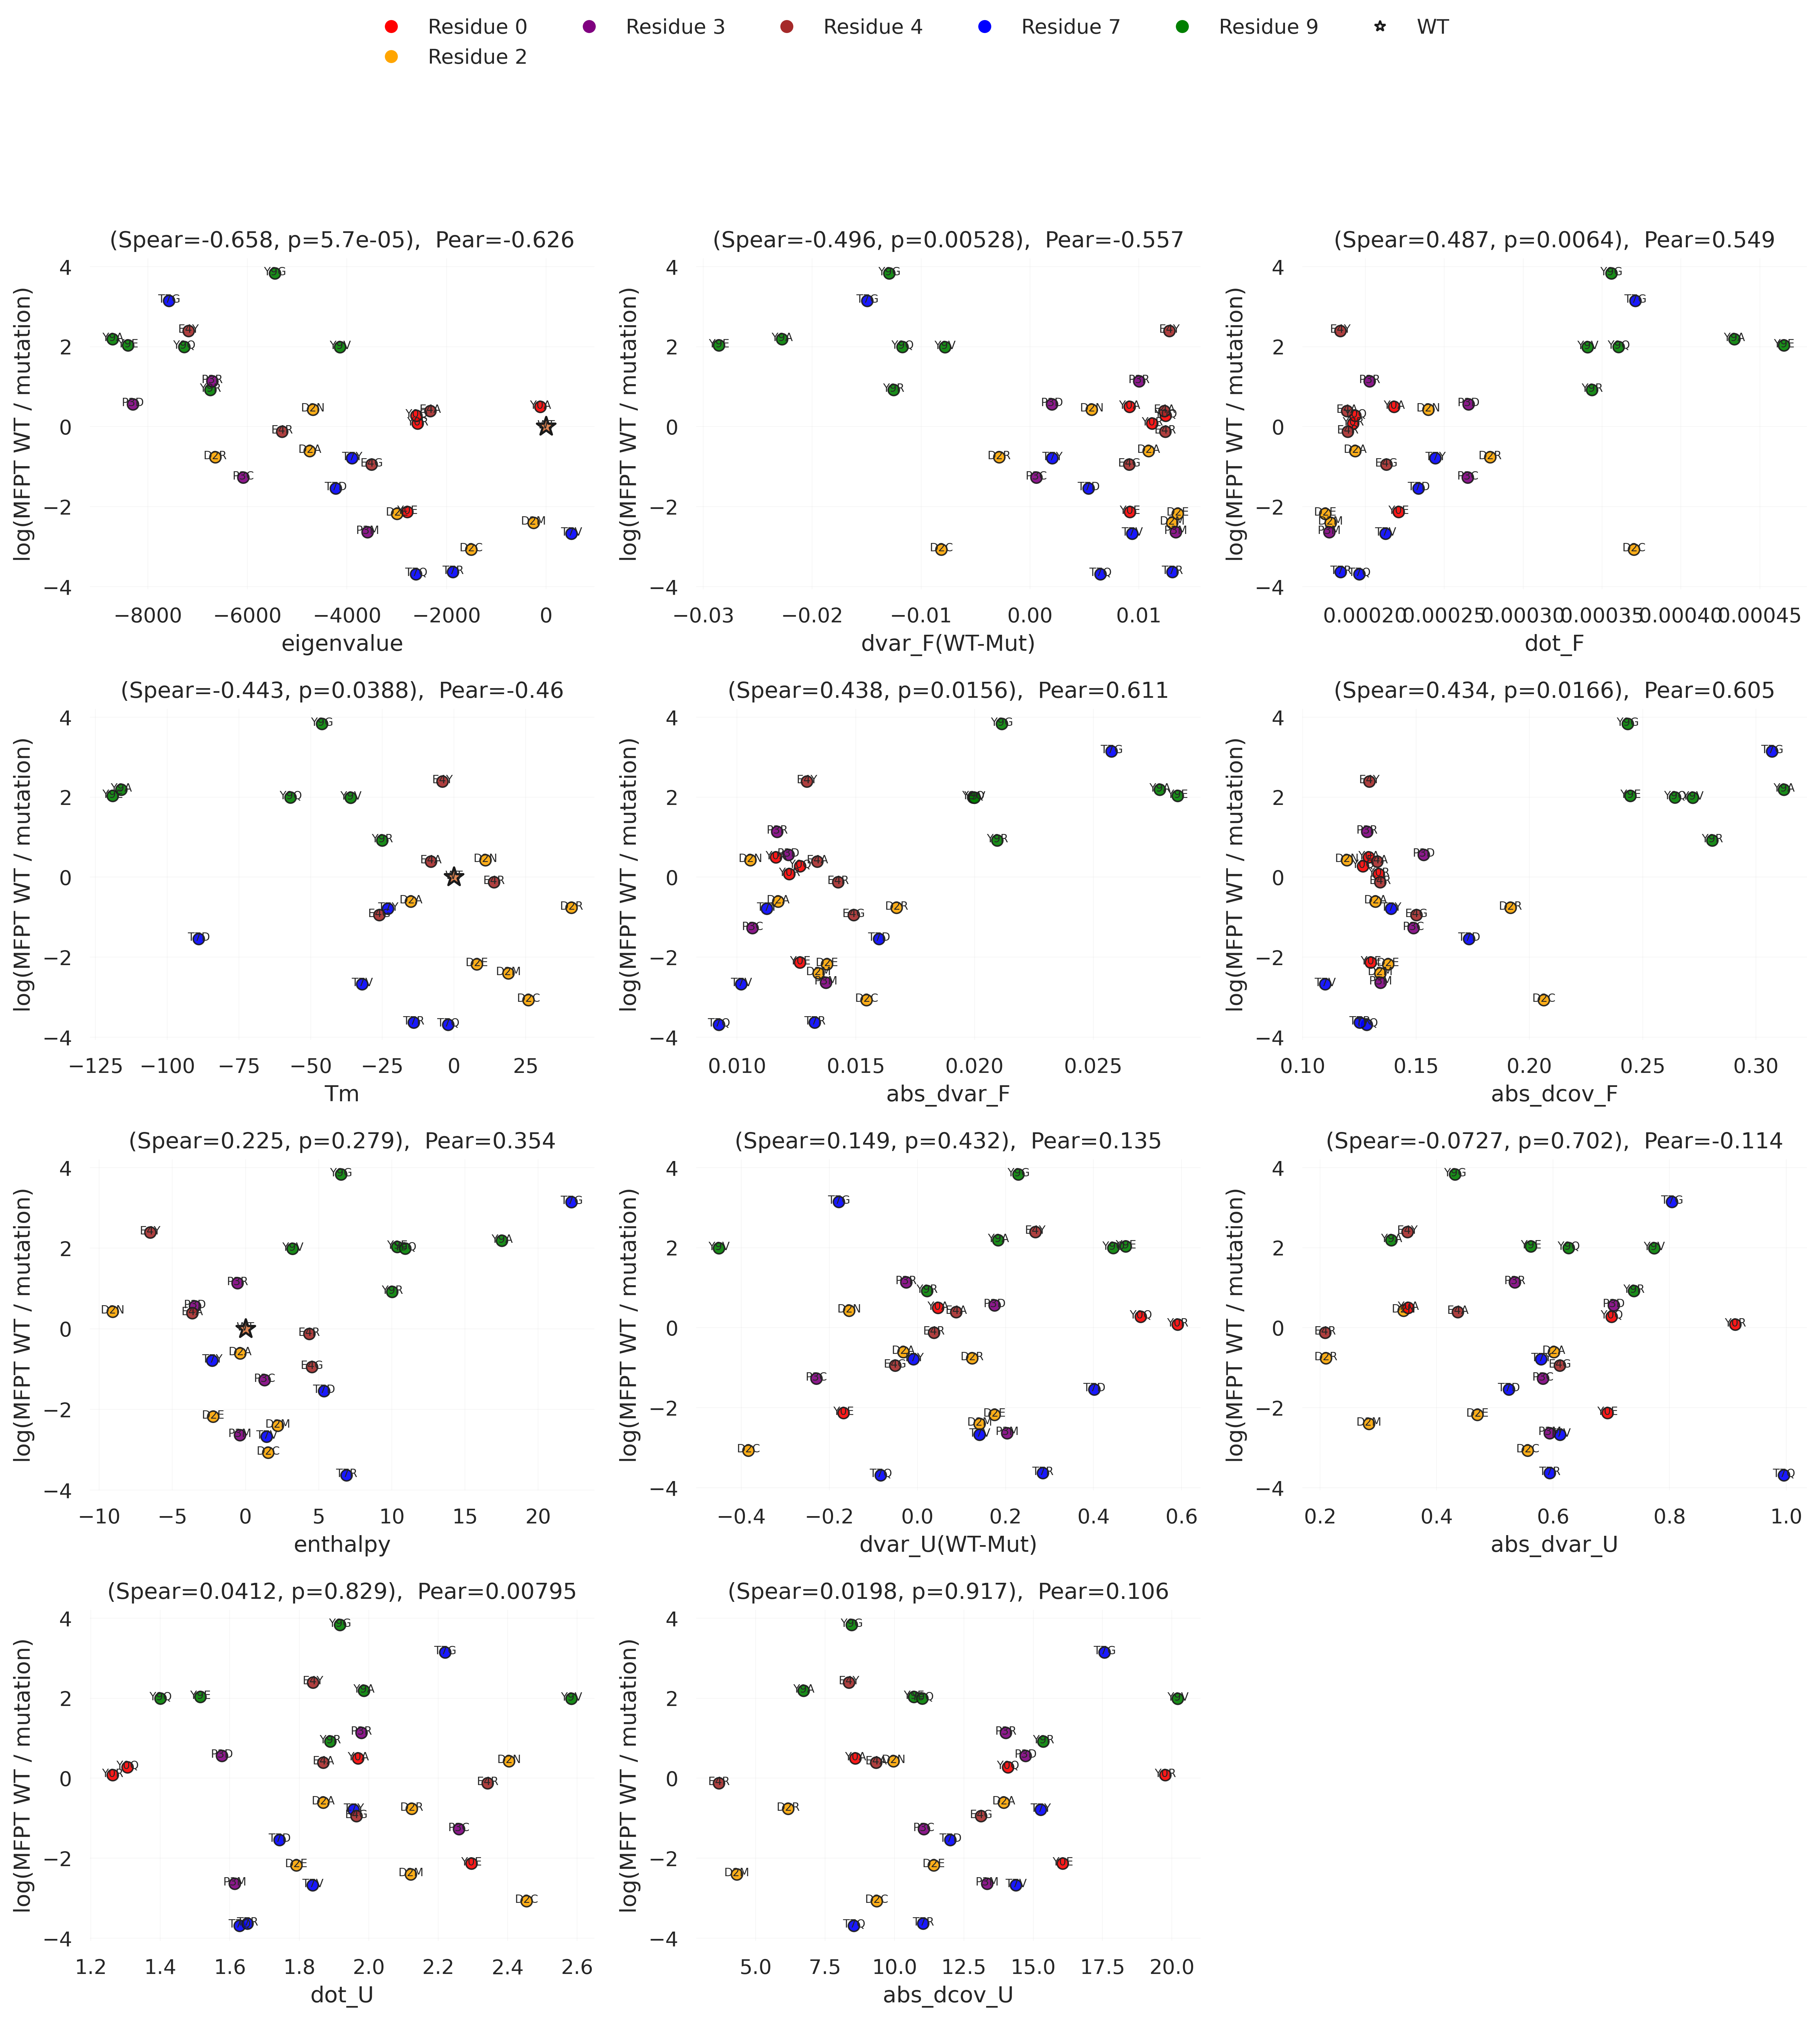

In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
import pickle
from common.consts import res_colors
from common.utils import collect_df, collect_df_best_p

sns.set_theme(context="notebook", style="white", rc={
    "axes.spines.left": False,
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.spines.bottom": False,
    "axes.grid": True,
    "grid.linewidth": 0.4,
    "grid.color": "#dddddd"
})

def plot_mfpt_corr_grid(
    df: pd.DataFrame,
    prop_cols,
    ncols=3
):
    wt_label = "WT"
    group_col = "residue_idx"
    res_keys = sorted(int(k) for k in df[group_col].dropna().unique())

    wt_mfpt = float(df.loc[wt_label, "mfpt"])
    y_all = np.log(wt_mfpt / df["mfpt"].to_numpy())
    names = df.index.to_numpy()
    wt_star = dict(s=110, marker="*", edgecolors="k", linewidths=1.2, zorder=4)

    x_cache, mask_cache, corr = {}, {}, {}

    for prop_col in prop_cols:
        wt_prop = df.loc[wt_label, prop_col]
        x_all = df[prop_col].to_numpy()
        if not pd.isna(wt_prop):
            x_all = x_all - wt_prop
        mask = np.isfinite(x_all) & np.isfinite(y_all)
        x_cache[prop_col] = x_all
        mask_cache[prop_col] = mask
        pearson_r, _ = stats.pearsonr(x_all[mask], y_all[mask])
        spearman_r, p = stats.spearmanr(x_all[mask], y_all[mask])
        corr[prop_col] = (spearman_r, p, pearson_r)

    ordered = sorted(prop_cols, key=lambda p: abs(corr[p][0]), reverse=True)
    n = len(ordered)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.8 * nrows), squeeze=False, dpi=200)

    for idx, prop_col in enumerate(ordered):
        ax = axes[idx // ncols][idx % ncols]
        x_all = x_cache[prop_col]
        mask = mask_cache[prop_col]
        wt_prop = df.loc[wt_label, prop_col]

        plot_df = pd.DataFrame({
            "x": x_all,
            "y": y_all,
            "name": names,
            group_col: df[group_col].to_numpy(),
            "valid": mask
        })

        sns.scatterplot(
            data=plot_df[plot_df["valid"]],
            x="x", y="y",
            hue=group_col,
            palette=res_colors,
            edgecolor="k",
            linewidth=0.8, 
            alpha=0.9,
            s=36,
            legend=False,
            ax=ax
        )

        if not pd.isna(wt_prop):
            ax.scatter(0, 0, **wt_star)

        for xv, yv, name, m in zip(x_all, y_all, names, mask):
            if m:
                ax.text(xv, yv - 0.1, name, fontsize=6, ha="center", va="bottom", zorder=5)

        spearman_r, p, pearson_r = corr[prop_col]
        ax.set_xlabel(prop_col)
        ax.set_ylabel("log(MFPT WT / mutation)")
        ax.set_title(f"(Spear={schoenen(spearman_r)}, p={schoenen(p)}),  Pear={schoenen(pearson_r)}")
        ax.grid(True, alpha=0.25)
        for spine in ax.spines.values():
            spine.set_visible(False)

    for j in range(n, nrows * ncols):
        fig.delaxes(axes[j // ncols][j % ncols])

    handles = [Line2D([0], [0], marker="o", linestyle="", color=res_colors[k], label=f"Residue {k}") for k in res_keys]
    handles.append(Line2D([0], [0], marker="*", linestyle="", color="w", markeredgecolor="k", label=wt_label))
    fig.legend(handles=handles, loc="upper center", ncol=min(len(handles), 6), frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()
    return corr

def schoenen(v):
    if np.isnan(v):
        return "nan"
    if abs(v) >= 0.001 or v == 0:
        return f"{v:.3g}"
    return f"{v:.1e}"

props = [
    "eigenvalue", "Tm", "enthalpy", "dvar_F(WT-Mut)", "dvar_U(WT-Mut)", "abs_dvar_F", "abs_dvar_U",
    "dot_F", "dot_U", "abs_dcov_F", "abs_dcov_U"
]

with open("../data/mfpt-pace=25000.pkl", "rb") as f:
    all_mfpt = pickle.load(f)

thresholds = np.sort(np.array(list(all_mfpt["chignolin"].keys()), dtype=float))
df = collect_df(False, all_mfpt, thresholds[1])
stats_map = plot_mfpt_corr_grid(df, props)


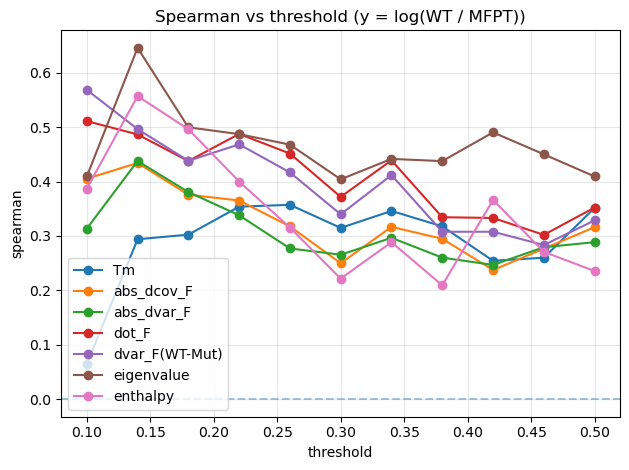

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import pickle
from common.utils import collect_df

def _robust_corr(x, y):
    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]; y = y[ok]
    n = x.size

    pear, p_pear = stats.pearsonr(x, y)
    spear, p_spear = stats.spearmanr(x, y)
    return pear, p_pear, spear, p_spear, n

def compute_corr_over_thresholds(all_mfpt, thresholds, protein, x_cols, y_col='mfpt', use_log_ratio_y=True):
    rows = []
    for th in thresholds:
        df = collect_df(False, all_mfpt, th)

        wt_prop_map = {}
        for x_col in x_cols:
            try:
                wt_prop_map[x_col] = df.loc['WT', x_col]
            except KeyError:
                wt_prop_map[x_col] = np.nan

        try:
            wt_mfpt = float(df.loc['WT', y_col])
        except KeyError:
            wt_mfpt = np.nan

        y_raw = pd.to_numeric(df.get(y_col), errors='coerce').to_numpy()
        if use_log_ratio_y:
            y = np.log(wt_mfpt / y_raw)
        else:
            y = wt_mfpt / y_raw

        for x_col in x_cols:
            x_series = pd.to_numeric(df.get(x_col), errors='coerce')
            wt_prop = wt_prop_map.get(x_col, np.nan)
            if not pd.isna(wt_prop):
                x = np.abs(x_series.to_numpy(dtype=float) - float(wt_prop))
            else:
                x = x_series.to_numpy(dtype=float)


            pear, p_pear, spear, p_spear, n = _robust_corr(x, y)
            rows.append({
                'protein': protein,
                'threshold': th,
                'x_col': x_col,
                'y_col': 'log(WT/{})'.format(y_col) if use_log_ratio_y else f'{y_col}_ratio_to_WT',
                'pearson': np.abs(pear),
                'pearson_p': p_pear,
                'spearman': np.abs(spear),
                'spearman_p': p_spear,
                'n': n,
            })
    return pd.DataFrame(rows).sort_values(['x_col', 'threshold'])

def plot_corr_vs_threshold(results_df, stat='pearson', title=None):
    xcols = results_df['x_col'].unique()
    for x_col in xcols:
        sub = results_df[results_df['x_col'] == x_col].sort_values('threshold')
        plt.plot(sub['threshold'], sub[stat], marker='o', label=x_col)
    plt.axhline(0, ls='--', alpha=0.4)
    plt.xlabel('threshold')
    plt.ylabel(stat)
    if title is None:
        title = f'{stat.capitalize()} vs threshold'
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

with open("../data/mfpt-pace=25000.pkl", "rb") as f:
    all_mfpt = pickle.load(f)

protein = 'chignolin'
thresholds = np.array(sorted(all_mfpt[protein].keys()))
x_cols = ["eigenvalue", "Tm", "enthalpy", "dvar_F(WT-Mut)",  "abs_dvar_F",  "dot_F",  "abs_dcov_F"]
y_col = 'mfpt'

res = compute_corr_over_thresholds(
    all_mfpt, thresholds, protein, x_cols,
    y_col=y_col, use_log_ratio_y=True
)

plot_corr_vs_threshold(res, stat='spearman', title='Spearman vs threshold (y = log(WT / MFPT))')
